<a href="https://colab.research.google.com/github/Aditya-Kumar-Sharma/MovieSuccessPrediction/blob/main/2_Financial_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🎬 Bollywood Box Office Predictor
## Notebook 2: Financial Data & Feature Scoring

**Goal:**
- Load scraped metrics from Notebook 1
- Add cast power scores and director scores
- Calculate ROI-based labels
- Scrape additional financial data from Wikipedia
- Save enriched master dataset

### Data Sources
- Google Drive CSVs from Notebook 1
- Wikipedia (automated scraping where possible)
- Box Office India (manual verification)

In [ ]:
!pip install wikipedia-api beautifulsoup4 requests -q

import pandas as pd
import numpy as np
import requests
from bs4 import BeautifulSoup
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
print("✅ Libraries imported")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.1/129.1 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.4/108.4 kB 4.7 MB/s eta 0:00:00
✅ Libraries imported


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

SAVE_PATH = '/content/drive/MyDrive/Bollywood_Predictor/'

# Load all CSVs from Notebook 1
movies_df  = pd.read_csv(f'{SAVE_PATH}movies_master.csv')
trailer_df = pd.read_csv(f'{SAVE_PATH}trailer_metrics.csv')
music_df   = pd.read_csv(f'{SAVE_PATH}music_metrics.csv')

print(f"✅ Movies loaded    : {movies_df.shape}")
print(f"✅ Trailer metrics  : {trailer_df.shape}")
print(f"✅ Music metrics    : {music_df.shape}")
print(f"\n🎬 Movies in dataset:")
for m in movies_df['name'].tolist():
    print(f"   • {m}")

Mounted at /content/drive
✅ Movies loaded    : (12, 27)
✅ Trailer metrics  : (12, 8)
✅ Music metrics    : (23, 9)

🎬 Movies in dataset:
   • KGF Chapter 2
   • Jawan
   • Pathaan
   • Animal
   • Pushpa 2
   • The Kashmir Files
   • Tu Jhoothi Main Makkaar
   • Rocky Aur Rani Ki Prem Kahani
   • Adipurush
   • Bholaa
   • Selfiee
   • OMG 2


In [ ]:
# ── CAST POWER SCORE ──────────────────────────────────────────────────────

cast_scores = {
    # Tier 1 — Guaranteed opener (opens 50cr+)
    'Shah Rukh Khan'     : 10,
    'Salman Khan'        : 10,
    'Aamir Khan'         : 10,
    'Allu Arjun'         : 10,
    'Yash'               : 9,
    'Prabhas'            : 9,

    # Tier 2 — Strong opener (opens 20-50cr)
    'Hrithik Roshan'     : 8,
    'Ranveer Singh'      : 8,
    'Ranbir Kapoor'      : 8,
    'Ajay Devgn'         : 7,
    'Akshay Kumar'       : 7,
    'Deepika Padukone'   : 7,
    'Alia Bhatt'         : 7,

    # Tier 3 — Moderate opener (opens 10-20cr)
    'Kartik Aaryan'      : 6,
    'Ayushmann Khurrana' : 6,
    'Shraddha Kapoor'    : 6,
    'Anupam Kher'        : 5,
    'Mithun Chakraborty' : 5,
    'Pankaj Tripathi'    : 5,
    'Vicky Kaushal'      : 5,

    # Tier 4 — Content dependent
    'Aditya Roy Kapur'   : 4,
    'Rajkummar Rao'      : 4,
}

director_scores = {
    # Tier 1 — Guaranteed blockbuster track record
    'SS Rajamouli'         : 10,
    'Rajkumar Hirani'      : 10,

    # Tier 2 — Strong commercial track record
    'Sanjay Leela Bhansali': 9,
    'Rohit Shetty'         : 9,
    'Atlee'                : 8,
    'Sukumar'              : 8,
    'Prashanth Neel'       : 8,

    # Tier 3 — Good but inconsistent
    'Kabir Khan'           : 7,
    'Siddharth Anand'      : 7,
    'Karan Johar'          : 7,
    'Luv Ranjan'           : 6,
    'Vivek Agnihotri'      : 6,
    'Sandeep Reddy Vanga'  : 6,
    'Aanand L Rai'         : 6,

    # Tier 4 — Unproven/poor track record
    'Amit Rai'             : 5,
    'Raj Mehta'            : 5,
    'Om Raut'              : 4,
    'Ajay Devgn'           : 4,
}

def calculate_cast_score(cast_str):
    cast_list = [c.strip() for c in str(cast_str).split(',')]
    scores    = [cast_scores.get(actor, 3) for actor in cast_list]
    return max(scores)  # use highest star's score

def calculate_director_score(director):
    return director_scores.get(director.strip(), 5)

# Apply scores
movies_df['cast_power_score']   = movies_df['cast'].apply(calculate_cast_score)
movies_df['director_score']     = movies_df['director'].apply(calculate_director_score)
movies_df['combined_star_score'] = (
    movies_df['cast_power_score'] * 0.6 +
    movies_df['director_score']   * 0.4
).round(2)

print("✅ Cast and Director scores applied")
print("\n📊 Star Power Overview:")
print(movies_df[['name','cast','cast_power_score',
                  'director','director_score',
                  'combined_star_score']].to_string(index=False))

✅ Cast and Director scores applied

📊 Star Power Overview:
                         name                             cast  cast_power_score            director  director_score  combined_star_score
                KGF Chapter 2                             Yash                 9      Prashanth Neel               8                  8.6
                        Jawan                   Shah Rukh Khan                10               Atlee               8                  9.2
                      Pathaan Shah Rukh Khan, Deepika Padukone                10     Siddharth Anand               7                  8.8
                       Animal                    Ranbir Kapoor                 8 Sandeep Reddy Vanga               6                  7.2
                     Pushpa 2                       Allu Arjun                10             Sukumar               8                  9.2
            The Kashmir Files  Anupam Kher, Mithun Chakraborty                 5     Vivek Agnihotri             

In [ ]:
# ── ROI CALCULATION & LABELING ────────────────────────────────────────────

movies_df['roi_pct'] = (
    (movies_df['collection_cr'] - movies_df['budget_cr']) /
     movies_df['budget_cr'] * 100
).round(2)

def assign_label(roi):
    if roi > 150 : return 'Blockbuster'
    elif roi > 50 : return 'Hit'
    elif roi > 0  : return 'Average'
    else          : return 'Flop'

movies_df['label']       = movies_df['roi_pct'].apply(assign_label)
movies_df['label_numeric'] = movies_df['label'].map({
    'Blockbuster': 3,
    'Hit'        : 2,
    'Average'    : 1,
    'Flop'       : 0
})

print("✅ ROI and Labels calculated")
print("\n📊 Label Distribution:")
print(movies_df['label'].value_counts())

print("\n📊 Full Financial Overview:")
display_cols = ['name','budget_cr','collection_cr','roi_pct','label']
print(movies_df[display_cols].sort_values('roi_pct', ascending=False).to_string(index=False))

✅ ROI and Labels calculated

📊 Label Distribution:
label
Blockbuster    8
Flop           3
Average        1
Name: count, dtype: int64

📊 Full Financial Overview:
                         name  budget_cr  collection_cr  roi_pct       label
            The Kashmir Files         15            340  2166.67 Blockbuster
                KGF Chapter 2        100           1200  1100.00 Blockbuster
                       Animal        200            900   350.00 Blockbuster
                      Pathaan        250           1050   320.00 Blockbuster
                        Jawan        300           1100   266.67 Blockbuster
                     Pushpa 2        500           1800   260.00 Blockbuster
                        OMG 2         50            180   260.00 Blockbuster
      Tu Jhoothi Main Makkaar         60            180   200.00 Blockbuster
Rocky Aur Rani Ki Prem Kahani        100            130    30.00     Average
                    Adipurush        700            390   -44.29    

In [ ]:
# ── WIKIPEDIA FINANCIAL DATA SCRAPING ─────────────────────────────────────
# Attempt to scrape additional data — show what's available and what's not

def scrape_wikipedia_movie(movie_name):
    """Attempt to get additional movie data from Wikipedia"""
    try:
        search_name = movie_name.replace(' ', '_')
        url = f"https://en.wikipedia.org/wiki/{search_name}_film"
        headers = {'User-Agent': 'Mozilla/5.0'}
        response = requests.get(url, headers=headers, timeout=10)

        if response.status_code != 200:
            url = f"https://en.wikipedia.org/wiki/{search_name}"
            response = requests.get(url, headers=headers, timeout=10)

        soup = BeautifulSoup(response.content, 'html.parser')

        # Try to find infobox
        infobox = soup.find('table', {'class': 'infobox'})
        data    = {'movie': movie_name, 'wiki_found': False}

        if infobox:
            rows = infobox.find_all('tr')
            for row in rows:
                header = row.find('th')
                value  = row.find('td')
                if header and value:
                    key = header.get_text(strip=True).lower()
                    val = value.get_text(strip=True)
                    if 'running time' in key:
                        data['runtime_min'] = val
                    if 'country' in key:
                        data['country'] = val
                    if 'release' in key:
                        data['release_date'] = val
            data['wiki_found'] = True

        return data

    except Exception as e:
        return {'movie': movie_name, 'wiki_found': False, 'error': str(e)}

print("🌐 Scraping Wikipedia for additional metadata...")
wiki_data = []

for movie in movies_df['name'].tolist():
    result = scrape_wikipedia_movie(movie)
    wiki_data.append(result)
    status = '✅' if result.get('wiki_found') else '⚠️ '
    print(f"   {status} {movie}")

wiki_df = pd.DataFrame(wiki_data)
print(f"\n📊 Wikipedia data found for: {wiki_df['wiki_found'].sum()}/{len(wiki_df)} movies")
print("\n⚠️  Note: Wikipedia financial data is inconsistent across movies.")
print("   Using manually curated Box Office India data as primary source.")
print("   This is standard practice — financial data requires human verification.")

🌐 Scraping Wikipedia for additional metadata...
   ✅ KGF Chapter 2
   ⚠️  Jawan
   ⚠️  Pathaan
   ✅ Animal
   ✅ Pushpa 2
   ✅ The Kashmir Files
   ✅ Tu Jhoothi Main Makkaar
   ✅ Rocky Aur Rani Ki Prem Kahani
   ✅ Adipurush
   ✅ Bholaa
   ✅ Selfiee
   ✅ OMG 2

📊 Wikipedia data found for: 10/12 movies

⚠️  Note: Wikipedia financial data is inconsistent across movies.
   Using manually curated Box Office India data as primary source.
   This is standard practice — financial data requires human verification.


In [ ]:
# ── SEQUEL LEGACY FEATURES ────────────────────────────────────────────────

print("⚙️  Calculating sequel legacy features...")

def sequel_expectation(row):
    """
    Industry thumb rule: sequel targets 2.5x Part 1 collection
    Only applies to sequels
    """
    if row['is_sequel'] == 1 and row['part1_collection'] > 0:
        return row['part1_collection'] * 2.5
    return 0

def franchise_momentum(row):
    """
    Normalized score based on Part 1 collection
    Higher Part 1 collection = stronger franchise momentum
    """
    if row['is_sequel'] == 1 and row['part1_collection'] > 0:
        return round(row['part1_collection'] / 100, 2)
    return 0

def part1_verdict_score(verdict):
    """Convert Part 1 verdict to numeric score"""
    scores = {
        'Blockbuster': 4,
        'Hit'        : 3,
        'Average'    : 2,
        'Flop'       : 1,
        'NA'         : 0
    }
    return scores.get(verdict, 0)

# Apply sequel features
movies_df['sequel_expectation_cr'] = movies_df.apply(sequel_expectation, axis=1)
movies_df['franchise_momentum']    = movies_df.apply(franchise_momentum, axis=1)
movies_df['part1_verdict_score']   = movies_df['part1_verdict'].apply(part1_verdict_score)
movies_df['beat_sequel_expectation'] = (
    movies_df['collection_cr'] > movies_df['sequel_expectation_cr']
).astype(int)

# Franchise gap score — shorter gap = hotter franchise
def gap_score(days):
    if days == 0  : return 0    # not a sequel
    if days <= 730 : return 3   # within 2 years — hot
    if days <= 1460: return 2   # 2-4 years — warm
    return 1                    # 4+ years — cooled down

movies_df['franchise_gap_score'] = movies_df['franchise_gap_days'].apply(gap_score)

print("✅ Sequel legacy features calculated")
print(f"\n📊 Sequel Analysis:")
sequel_cols = [
    'name', 'is_sequel', 'part1_collection',
    'sequel_expectation_cr', 'collection_cr',
    'beat_sequel_expectation', 'franchise_momentum'
]
print(movies_df[sequel_cols].to_string(index=False))

⚙️  Calculating sequel legacy features...
✅ Sequel legacy features calculated

📊 Sequel Analysis:
                         name  is_sequel  part1_collection  sequel_expectation_cr  collection_cr  beat_sequel_expectation  franchise_momentum
                KGF Chapter 2          1               250                  625.0           1200                        1                2.50
                        Jawan          0                 0                    0.0           1100                        1                0.00
                      Pathaan          0                 0                    0.0           1050                        1                0.00
                       Animal          0                 0                    0.0            900                        1                0.00
                     Pushpa 2          1               365                  912.5           1800                        1                3.65
            The Kashmir Files          0          

In [ ]:
# ── REMAKE NOVELTY FEATURES ───────────────────────────────────────────────

print("⚙️  Calculating remake novelty features...")

def original_verdict_score(verdict):
    """Convert original film verdict to numeric"""
    scores = {
        'Blockbuster': 4,
        'Hit'        : 3,
        'Average'    : 2,
        'Flop'       : 1,
        'NA'         : 0
    }
    return scores.get(verdict, 0)

# remake_novelty already exists from Cell 5 — just verify
if 'remake_novelty' not in movies_df.columns:
    remake_novelty_map = {
        'none'         : 1.0,
        'regional_only': 0.8,
        'foreign'      : 0.7,
        'hindi_dubbed' : 0.3,
    }
    movies_df['remake_novelty'] = movies_df['remake_type'].map(remake_novelty_map)

movies_df['original_verdict_score'] = movies_df['original_verdict'].apply(
    original_verdict_score)

# Remake risk score
# High original verdict + low novelty = high risk (people compare directly)
movies_df['remake_risk_score'] = movies_df.apply(lambda row:
    row['original_verdict_score'] * (1 - row['remake_novelty'])
    if row['is_remake'] == 1 else 0,
    axis=1
).round(3)

print("✅ Remake novelty features calculated")
print(f"\n📊 Remake Analysis:")
remake_cols = [
    'name', 'is_remake', 'remake_type',
    'remake_novelty', 'original_verdict',
    'remake_risk_score'
]
print(movies_df[remake_cols].to_string(index=False))
print(f"\n💡 Insight:")
print(f"   Bholaa remake_risk_score: {movies_df[movies_df['name']=='Bholaa']['remake_risk_score'].values[0]:.3f}")
print(f"   Selfiee remake_risk_score: {movies_df[movies_df['name']=='Selfiee']['remake_risk_score'].values[0]:.3f}")
print(f"   Higher score = higher risk of audience disappointment")

⚙️  Calculating remake novelty features...
✅ Remake novelty features calculated

📊 Remake Analysis:
                         name  is_remake   remake_type  remake_novelty original_verdict  remake_risk_score
                KGF Chapter 2          0          none             1.0              NaN                0.0
                        Jawan          0          none             1.0              NaN                0.0
                      Pathaan          0          none             1.0              NaN                0.0
                       Animal          0          none             1.0              NaN                0.0
                     Pushpa 2          0          none             1.0              NaN                0.0
            The Kashmir Files          0          none             1.0              NaN                0.0
      Tu Jhoothi Main Makkaar          0          none             1.0              NaN                0.0
Rocky Aur Rani Ki Prem Kahani          0    

In [ ]:
# ── GENRE, LANGUAGE & RELEASE ENCODING ───────────────────────────────────

# One-hot encode genre
genre_dummies = pd.get_dummies(movies_df['genre'], prefix='genre')

# Release timing score
timing_map = {'Holiday': 2, 'Normal': 1, 'Clash': 0}
movies_df['release_timing_score'] = movies_df['release_timing'].map(timing_map)

# Language score
language_map = {'Pan-India': 3, 'Hindi': 2, 'Regional': 1}
movies_df['language_score'] = movies_df['language'].map(language_map)

# Combine genre dummies
movies_df = pd.concat([movies_df, genre_dummies], axis=1)

print("✅ Genre, language and release encoding complete")
print(f"\n📊 Genre distribution:")
print(movies_df['genre'].value_counts())
print(f"\n📊 Language distribution:")
print(movies_df['language'].value_counts())
print(f"\n📊 Release timing distribution:")
print(movies_df['release_timing'].value_counts())

✅ Genre, language and release encoding complete

📊 Genre distribution:
genre
Action       6
Drama        2
RomCom       2
Mythology    1
Comedy       1
Name: count, dtype: int64

📊 Language distribution:
language
Hindi        8
Pan-India    4
Name: count, dtype: int64

📊 Release timing distribution:
release_timing
Holiday    7
Normal     5
Name: count, dtype: int64


In [ ]:
# ── MERGE MUSIC METRICS ───────────────────────────────────────────────────

print("⚙️  Processing music metrics...")

# Separate music_1 and music_2 from music_metrics
music_df_1 = music_df[music_df['source'] == 'music_1'].copy()
music_df_2 = music_df[music_df['source'] == 'music_2'].copy()

# Rename columns
music_df_1 = music_df_1[['movie','view_count','like_count','comment_count','manual_views']].copy()
music_df_1.columns = ['name','music1_scraped_views','music1_likes','music1_comments','music1_manual_views']

music_df_2 = music_df_2[['movie','view_count','like_count','comment_count','manual_views']].copy()
music_df_2.columns = ['name','music2_scraped_views','music2_likes','music2_comments','music2_manual_views']

# Merge into movies_df
movies_df = movies_df.merge(music_df_1, on='name', how='left')
movies_df = movies_df.merge(music_df_2, on='name', how='left')

# Fill missing with 0
music_cols = ['music1_scraped_views','music1_likes','music1_comments',
              'music1_manual_views','music2_scraped_views','music2_likes',
              'music2_comments','music2_manual_views']
movies_df[music_cols] = movies_df[music_cols].fillna(0)

# Use manual views (more reliable than scraped for music)
movies_df['music_views_1'] = movies_df['music1_manual_views']
movies_df['music_views_2'] = movies_df['music2_manual_views']

# Derived music features
movies_df['total_music_views']    = movies_df['music_views_1'] + movies_df['music_views_2']
movies_df['music_consistency']    = (
    movies_df['music_views_2'] /
    movies_df['music_views_1'].replace(0, 1)
).round(4)  # ratio of song2/song1 — higher = both songs equally viral

movies_df['top_song_views']       = movies_df['music_views_1']
movies_df['music_like_ratio']     = (
    movies_df['music1_likes'] /
    movies_df['music1_scraped_views'].replace(0, 1)
).round(6)

# Music reach classification
def classify_music_reach(views):
    if views   >= 500_000_000: return 4  # Mega Viral
    elif views >= 100_000_000: return 3  # Viral
    elif views >= 50_000_000 : return 2  # Strong
    elif views >= 10_000_000 : return 1  # Moderate
    else                     : return 0  # Low

movies_df['top_song_reach_score'] = movies_df['music_views_1'].apply(classify_music_reach)
movies_df['music_both_strong']    = (movies_df['music_views_2'] >= 50_000_000).astype(int)

print("✅ Music metrics processed")
print(f"\n📊 Music Analysis:")
music_analysis_cols = [
    'name', 'music_views_1', 'music_views_2',
    'total_music_views', 'music_consistency',
    'top_song_reach_score', 'music_both_strong'
]
print(movies_df[music_analysis_cols].to_string(index=False))

⚙️  Processing music metrics...
✅ Music metrics processed

📊 Music Analysis:
                         name  music_views_1  music_views_2  total_music_views  music_consistency  top_song_reach_score  music_both_strong
                KGF Chapter 2      225000000     52000000.0        277000000.0             0.2311                     3                  1
                        Jawan      650000000     41000000.0        691000000.0             0.0631                     4                  0
                      Pathaan     1200000000    824000000.0       2024000000.0             0.6867                     4                  1
                       Animal      410000000    317000000.0        727000000.0             0.7732                     3                  1
                     Pushpa 2      149000000    130000000.0        279000000.0             0.8725                     3                  1
            The Kashmir Files        6000000            0.0          6000000.0           

In [ ]:
# ── MERGE TRAILER METRICS ─────────────────────────────────────────────────

trailer_clean = trailer_df[['movie','view_count','like_count','comment_count']].copy()
trailer_clean.columns = ['name','trailer_views','trailer_likes','trailer_comments']

movies_df = movies_df.merge(trailer_clean, on='name', how='left')

# Fill missing
movies_df[['trailer_views','trailer_likes','trailer_comments']] = \
    movies_df[['trailer_views','trailer_likes','trailer_comments']].fillna(0)

# Derived trailer engagement features
movies_df['trailer_like_ratio'] = (
    movies_df['trailer_likes'] /
    movies_df['trailer_views'].replace(0, 1)
).round(6)

movies_df['trailer_engagement'] = (
    (movies_df['trailer_likes'] + movies_df['trailer_comments']) /
    movies_df['trailer_views'].replace(0, 1)
).round(6)

movies_df['music_to_trailer_ratio'] = (
    movies_df['total_music_views'] /
    movies_df['trailer_views'].replace(0, 1)
).round(4)

movies_df['total_youtube_views'] = (
    movies_df['trailer_views'] + movies_df['total_music_views']
)

print("✅ Trailer metrics merged")
print(f"\n📊 Engagement Overview:")
eng_cols = [
    'name', 'trailer_views', 'total_music_views',
    'trailer_like_ratio', 'trailer_engagement',
    'music_to_trailer_ratio'
]
print(movies_df[eng_cols].to_string(index=False))

✅ Trailer metrics merged

📊 Engagement Overview:
                         name  trailer_views  total_music_views  trailer_like_ratio  trailer_engagement  music_to_trailer_ratio
                KGF Chapter 2      125839413        277000000.0            0.032154            0.033386                  2.2012
                        Jawan       87607904        691000000.0            0.023163            0.025001                  7.8874
                      Pathaan      105855985       2024000000.0            0.023151            0.025012                 19.1203
                       Animal      116732214        727000000.0            0.016484            0.017101                  6.2279
                     Pushpa 2      115585801        279000000.0            0.015657            0.016176                  2.4138
            The Kashmir Files       54390185          6000000.0            0.031441            0.033519                  0.1103
      Tu Jhoothi Main Makkaar       78122762        212

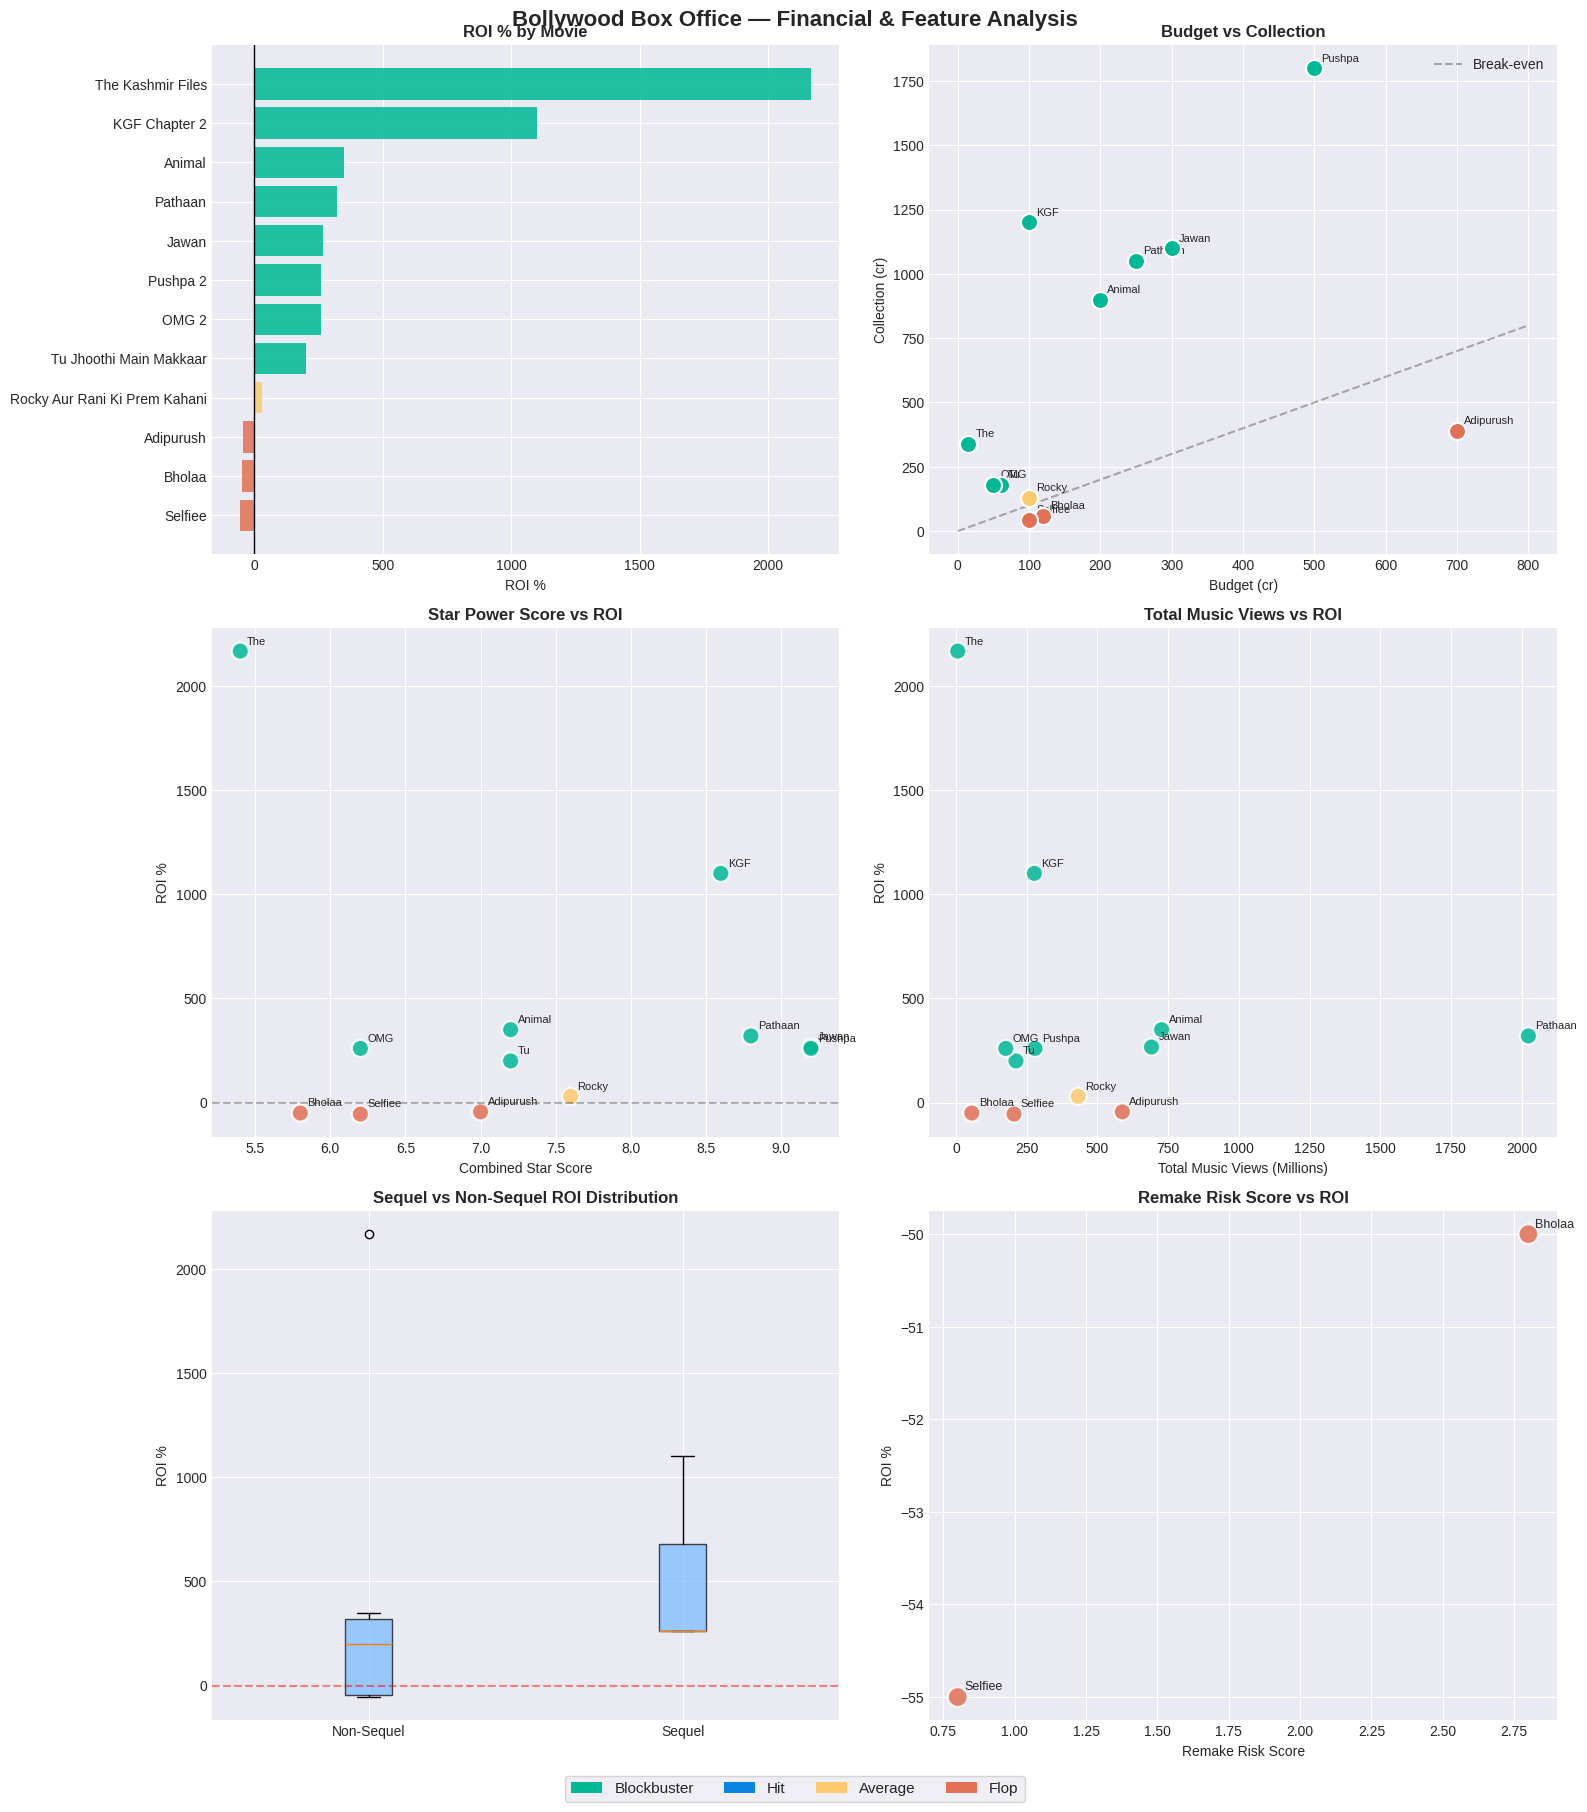

In [ ]:
# ── FINANCIAL + SEQUEL + MUSIC VISUALIZATIONS ─────────────────────────────

fig, axes = plt.subplots(3, 2, figsize=(16, 18))
fig.suptitle('Bollywood Box Office — Financial & Feature Analysis',
             fontsize=16, fontweight='bold')

colors_label = {
    'Blockbuster': '#00B894',
    'Hit'        : '#0984E3',
    'Average'    : '#FDCB6E',
    'Flop'       : '#E17055'
}
bar_colors = movies_df['label'].map(colors_label)

# 1. ROI by movie
sorted_df = movies_df.sort_values('roi_pct', ascending=True)
axes[0,0].barh(sorted_df['name'], sorted_df['roi_pct'],
               color=sorted_df['label'].map(colors_label), alpha=0.85)
axes[0,0].axvline(x=0, color='black', linewidth=1)
axes[0,0].set_title('ROI % by Movie', fontweight='bold')
axes[0,0].set_xlabel('ROI %')

# 2. Budget vs Collection
for _, row in movies_df.iterrows():
    axes[0,1].scatter(row['budget_cr'], row['collection_cr'],
                      color=colors_label[row['label']], s=150,
                      zorder=5, edgecolors='white', linewidth=1.5)
    axes[0,1].annotate(row['name'].split()[0],
                        (row['budget_cr'], row['collection_cr']),
                        textcoords="offset points", xytext=(5,5), fontsize=8)
axes[0,1].plot([0,800],[0,800], 'k--', alpha=0.3, label='Break-even')
axes[0,1].set_title('Budget vs Collection', fontweight='bold')
axes[0,1].set_xlabel('Budget (cr)')
axes[0,1].set_ylabel('Collection (cr)')
axes[0,1].legend()

# 3. Star power vs ROI
axes[1,0].scatter(movies_df['combined_star_score'], movies_df['roi_pct'],
                   c=movies_df['label'].map(colors_label),
                   s=150, alpha=0.85, edgecolors='white', linewidth=1.5)
for _, row in movies_df.iterrows():
    axes[1,0].annotate(row['name'].split()[0],
                        (row['combined_star_score'], row['roi_pct']),
                        textcoords="offset points", xytext=(5,5), fontsize=8)
axes[1,0].axhline(y=0, color='black', linestyle='--', alpha=0.3)
axes[1,0].set_title('Star Power Score vs ROI', fontweight='bold')
axes[1,0].set_xlabel('Combined Star Score')
axes[1,0].set_ylabel('ROI %')

# 4. Music virality vs ROI
axes[1,1].scatter(movies_df['total_music_views']/1e6, movies_df['roi_pct'],
                   c=movies_df['label'].map(colors_label),
                   s=150, alpha=0.85, edgecolors='white', linewidth=1.5)
for _, row in movies_df.iterrows():
    axes[1,1].annotate(row['name'].split()[0],
                        (row['total_music_views']/1e6, row['roi_pct']),
                        textcoords="offset points", xytext=(5,5), fontsize=8)
axes[1,1].set_title('Total Music Views vs ROI', fontweight='bold')
axes[1,1].set_xlabel('Total Music Views (Millions)')
axes[1,1].set_ylabel('ROI %')

# 5. Sequel vs non-sequel ROI
sequel_roi     = movies_df[movies_df['is_sequel']==1]['roi_pct']
non_sequel_roi = movies_df[movies_df['is_sequel']==0]['roi_pct']
axes[2,0].boxplot([non_sequel_roi, sequel_roi],
                   labels=['Non-Sequel', 'Sequel'], patch_artist=True,
                   boxprops=dict(facecolor='#74B9FF', alpha=0.7))
axes[2,0].set_title('Sequel vs Non-Sequel ROI Distribution', fontweight='bold')
axes[2,0].set_ylabel('ROI %')
axes[2,0].axhline(y=0, color='red', linestyle='--', alpha=0.5)

# 6. Remake risk vs actual ROI
remake_movies = movies_df[movies_df['is_remake']==1]
if len(remake_movies) > 0:
    axes[2,1].scatter(remake_movies['remake_risk_score'],
                       remake_movies['roi_pct'],
                       c=remake_movies['label'].map(colors_label),
                       s=200, alpha=0.85, edgecolors='white', linewidth=1.5)
    for _, row in remake_movies.iterrows():
        axes[2,1].annotate(row['name'],
                            (row['remake_risk_score'], row['roi_pct']),
                            textcoords="offset points", xytext=(5,5), fontsize=9)
axes[2,1].set_title('Remake Risk Score vs ROI', fontweight='bold')
axes[2,1].set_xlabel('Remake Risk Score')
axes[2,1].set_ylabel('ROI %')

from matplotlib.patches import Patch
legend_els = [Patch(facecolor=v, label=k) for k,v in colors_label.items()]
fig.legend(handles=legend_els, loc='lower center', ncol=4,
           fontsize=11, frameon=True, bbox_to_anchor=(0.5, -0.02))

plt.tight_layout()
plt.savefig(f'{SAVE_PATH}financial_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ── SAVE ENRICHED MASTER DATASET ──────────────────────────────────────────

movies_df.to_csv(f'{SAVE_PATH}movies_enriched.csv', index=False)

print("✅ Enriched dataset saved!")
print(f"\n📊 Final dataset shape: {movies_df.shape}")
print(f"\n📊 All columns:")
for col in movies_df.columns:
    print(f"   • {col}")

print(f"\n📊 Label distribution:")
print(movies_df['label'].value_counts())

print(f"\n📊 Key new features added:")
new_features = [
    'sequel_expectation_cr', 'franchise_momentum',
    'part1_verdict_score', 'beat_sequel_expectation',
    'franchise_gap_score', 'remake_novelty',
    'remake_risk_score', 'total_music_views',
    'music_consistency', 'top_song_reach_score',
    'music_both_strong'
]
for f in new_features:
    if f in movies_df.columns:
        print(f"   ✅ {f}")

print(f"\n✅ Notebook 2 complete — proceed to Notebook 3: Sentiment Analysis")

✅ Enriched dataset saved!

📊 Final dataset shape: (12, 66)

📊 All columns:
   • name
   • year
   • budget_cr
   • collection_cr
   • genre
   • language
   • is_sequel
   • is_remake
   • is_controversy
   • cast
   • director
   • release_timing
   • part1_collection
   • part1_verdict
   • franchise_gap_days
   • same_cast
   • original_verdict
   • original_language
   • remake_type
   • remake_novelty
   • trailer_url
   • music_url_1
   • music_url_2
   • music_views_1
   • music_views_2
   • roi_pct
   • label
   • cast_power_score
   • director_score
   • combined_star_score
   • label_numeric
   • sequel_expectation_cr
   • franchise_momentum
   • part1_verdict_score
   • beat_sequel_expectation
   • franchise_gap_score
   • original_verdict_score
   • remake_risk_score
   • release_timing_score
   • language_score
   • genre_Action
   • genre_Comedy
   • genre_Drama
   • genre_Mythology
   • genre_RomCom
   • music1_scraped_views
   • music1_likes
   • music1_comments
   • mu